# 01 - Exploratory Data Analysis

**Goal:** Understand the energy consumption dataset before building any models.  

**Dataset:** Hourly data from Spain (2015–2018) covering energy consumption, generation by source, electricity prices, and weather across 5 cities.

## 1. Load and Inspect

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

energy = pd.read_csv('../data/energy_dataset.csv')
weather = pd.read_csv('../data/weather_features.csv')

energy['time'] = pd.to_datetime(energy['time'], utc=True).dt.tz_localize(None)
weather['dt_iso'] = pd.to_datetime(weather['dt_iso'], utc=True).dt.tz_localize(None)

print('Energy shape:', energy.shape)
print('Weather shape:', weather.shape)

Energy shape: (35064, 29)
Weather shape: (178396, 17)


In [58]:
energy.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2014-12-31 23:00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 00:00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 01:00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 02:00:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 03:00:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [59]:
energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   time                                         35064 non-null  datetime64[ns]
 1   generation biomass                           35045 non-null  float64       
 2   generation fossil brown coal/lignite         35046 non-null  float64       
 3   generation fossil coal-derived gas           35046 non-null  float64       
 4   generation fossil gas                        35046 non-null  float64       
 5   generation fossil hard coal                  35046 non-null  float64       
 6   generation fossil oil                        35045 non-null  float64       
 7   generation fossil oil shale                  35046 non-null  float64       
 8   generation fossil peat                       35046 non-null  float64       


In [60]:
energy.describe().T

,count,mean,min,25%,50%,75%,max,std
time,35064,2016-12-31 10:30:00,2014-12-31 23:00:00,2016-01-01 04:45:00,2016-12-31 10:30:00,2017-12-31 16:15:00,2018-12-31 22:00:00,NaN
generation biomass,35045.0,383.51354,0.0,333.0,367.0,433.0,592.0,85.353943
generation fossil brown coal/lignite,35046.0,448.059208,0.0,0.0,509.0,757.0,999.0,354.56859
generation fossil coal-derived gas,35046.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
generation fossil gas,35046.0,5622.737488,0.0,4126.0,4969.0,6429.0,20034.0,2201.830478
generation fossil hard coal,35046.0,4256.065742,0.0,2527.0,4474.0,5838.75,8359.0,1961.601013
generation fossil oil,35045.0,298.319789,0.0,263.0,300.0,330.0,449.0,52.520673
generation fossil oil shale,35046.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
generation fossil peat,35046.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
generation geothermal,35046.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


There are 2 columns that only have null values. Plus some columns only have zeros. They will need to be dropped from analysis.

### Missing Values

In [61]:
missing = energy.isnull().sum()
missing_pct = (missing / len(energy) * 100).round(1)
pd.DataFrame({'count': missing, 'pct': missing_pct}).query('count > 0').sort_values('pct', ascending=False)

,count,pct
forecast wind offshore eday ahead,35064,100.0
generation hydro pumped storage aggregated,35064,100.0
generation biomass,19,0.1
generation hydro water reservoir,18,0.1
generation wind onshore,18,0.1
generation wind offshore,18,0.1
generation waste,19,0.1
generation solar,18,0.1
generation other renewable,18,0.1
generation other,18,0.1


The columns with 100% data should be dropped, others have small number of missing data which shouldn't impact the results significantly. A simple forward-fill in this case would suffice. But the "generation" variables won't be used in the forecasting model because of the leakage. At prediction time (24 hours ahead), we don't know how much solar, wind, or gas generation there will be tomorrow. We could try using "forecast solar day ahead" and "forecast wind onshore day ahead" as those are genuine forecasts, but wind or solar forecasts are mostly weather-dependent and we have access to a separate weather dataset. We could check how these columns compare against our weather features.

However, if we wanted we could implement a more presonalised way of imputation adjusting it depending on the column. Someone on Kaggle has already investigated missingness in greater detail -> [Kaggle discussion](https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather/discussion/543663)

Our target variable "total load actual" has 36 missing data points. I could choose to implement polynomial order 5 interpolation because demand follows a smooth curve throughout the day, not a straight line, as shown in the Kaggle notebook above.

## 2. Target Variable

Our target is `total load actual` - the actual energy consumption per hour.

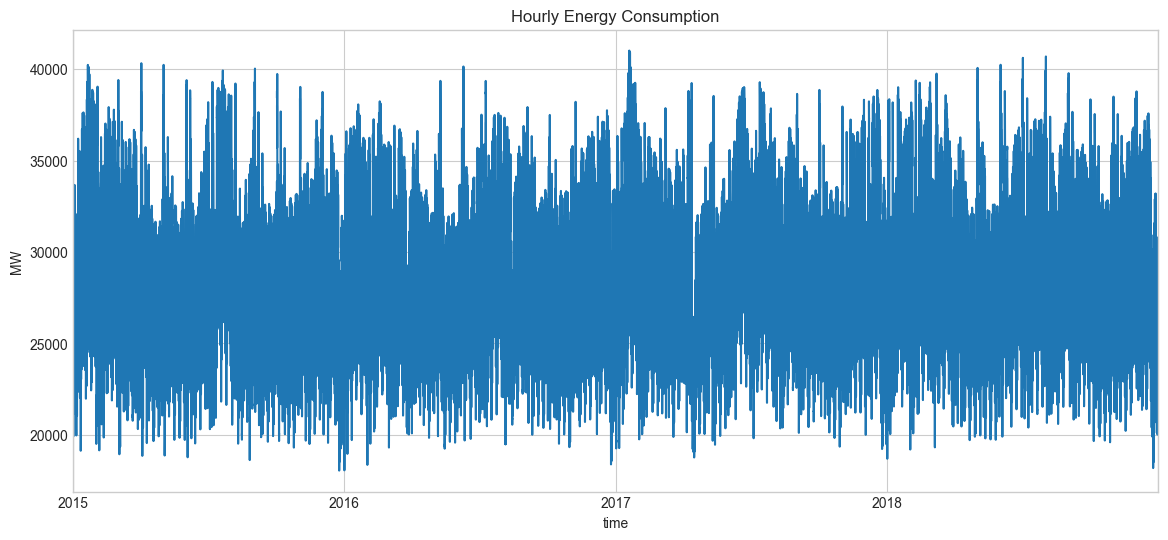

In [62]:
energy.set_index('time')['total load actual'].plot(title='Hourly Energy Consumption')
plt.ylabel('MW')
plt.show()

No obvious trend, demand isn't growing or shrinking over the 4 years. But there is visible seasonality.

In [80]:
# Top 10 highest demand hours
print('=== Highest Demand ===')
print(energy.nlargest(15, 'total load actual')[['time', 'total load actual']].to_string(index=False))

print('\n=== Lowest Demand ===')
print(energy.nsmallest(10, 'total load actual')[['time', 'total load actual']].to_string(index=False))

=== Highest Demand ===
               time  total load actual
2017-01-18 19:00:00            41015.0
2017-01-18 18:00:00            40939.0
2017-01-19 18:00:00            40916.0
2017-01-19 19:00:00            40900.0
2018-08-02 18:00:00            40693.0
2018-07-02 18:00:00            40620.0
2015-04-02 18:00:00            40324.0
2015-04-02 17:00:00            40306.0
2017-01-19 10:00:00            40295.0
2018-08-02 17:00:00            40241.0
2018-06-02 18:00:00            40239.0
2015-05-02 18:00:00            40234.0
2015-01-20 18:00:00            40232.0
2015-01-20 19:00:00            40207.0
2016-06-09 11:00:00            40144.0

=== Lowest Demand ===
               time  total load actual
2015-12-25 04:00:00            18041.0
2016-01-01 04:00:00            18054.0
2015-12-25 03:00:00            18178.0
2018-12-25 04:00:00            18179.0
2016-01-01 05:00:00            18234.0
2015-12-25 05:00:00            18253.0
2018-12-25 03:00:00            18279.0
2016-01-01 03:00:0

In [81]:
# Check temperature on peak demand dates
# '2015-04-02' Thursday before Easter
peak_dates = ['2017-01-18', '2017-01-19', '2018-08-02', '2018-07-02', '2015-04-02', '2018-06-02']

for date in peak_dates:
    day_mask = (weather['dt_iso'].dt.date.astype(str) == date)
    day_data = weather[day_mask]
    
    daytime = day_data[day_data['dt_iso'].dt.hour.between(8, 20)]['temp'].mean() - 273.15
    nighttime = day_data[~day_data['dt_iso'].dt.hour.between(8, 20)]['temp'].mean() - 273.15
    
    print(f'{date}: day {daytime:.1f}°C | night {nighttime:.1f}°C')

2017-01-18: day 5.1°C | night 1.7°C
2017-01-19: day 6.8°C | night 2.8°C
2018-08-02: day 32.8°C | night 24.5°C
2018-07-02: day 26.6°C | night 20.4°C
2015-04-02: day 16.5°C | night 9.4°C
2018-06-02: day 20.5°C | night 16.2°C


The lowest demand seems to be around the time of holidays, Christmas and New Year. This suggests we could add holiday indicators to improve the model. The highest demand seems to be driven partly by very low and high temperatures plus holidays.

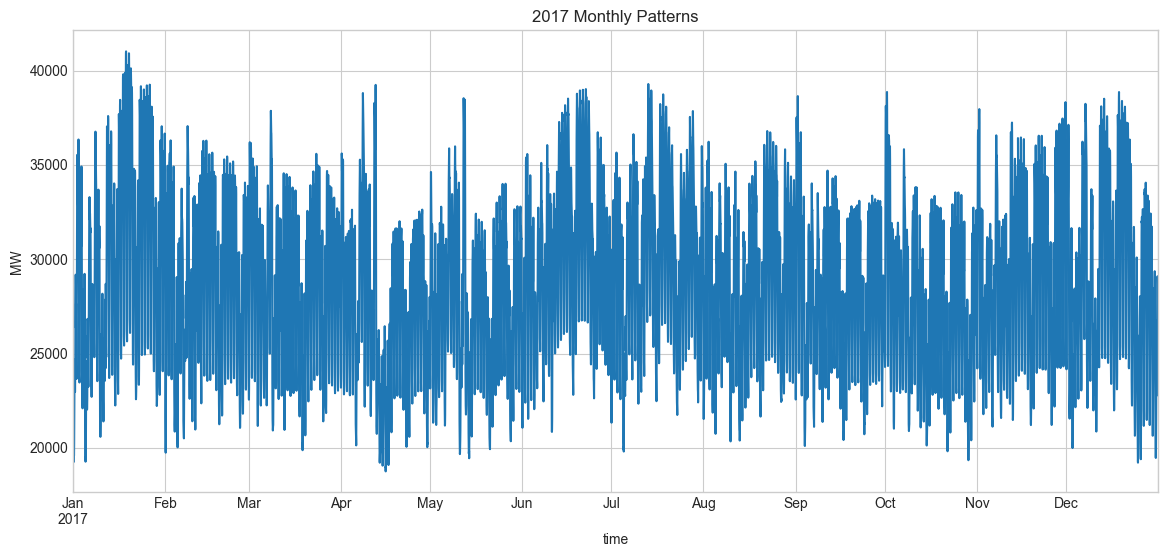

In [95]:
energy.set_index('time')['total load actual']['2017'].plot(title='2017 Monthly Patterns')
plt.ylabel('MW')
plt.show()

There is a slight seasonal pattern with winter and summer showing higher demands likely because of heating/cooling. There is also a dip around Easter. Weekly cycling is visible.

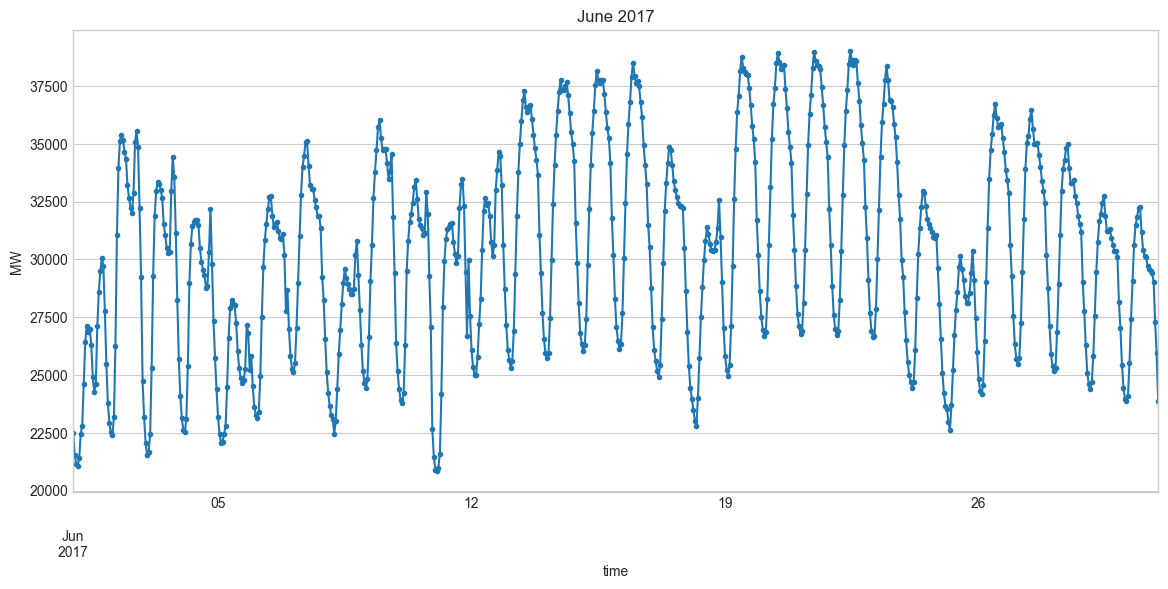

In [97]:
energy.set_index('time')['total load actual']['2017-06-01':'2017-06-30'].plot(
    title='June 2017', marker='.')
plt.ylabel('MW')
plt.show()

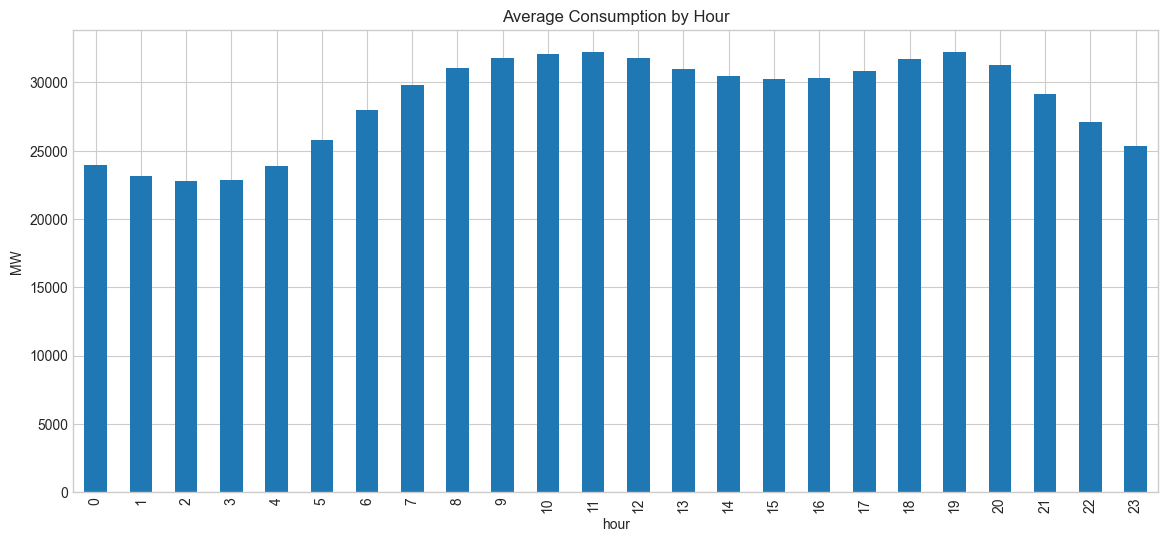

In [98]:
energy['hour'] = energy['time'].dt.hour
energy.groupby('hour')['total load actual'].mean().plot(kind='bar', title='Average Consumption by Hour')
plt.ylabel('MW')
plt.show()

Many days have two peaks (one mid-morning, one evening around 8-9pm) with a dip in the afternoon. Could be explained by a siesta/lunch lull break in Spain.  
Demand drops overnight, then climbs back up in the morning.
Weekend peaks seem to be lower than the weekday ones.

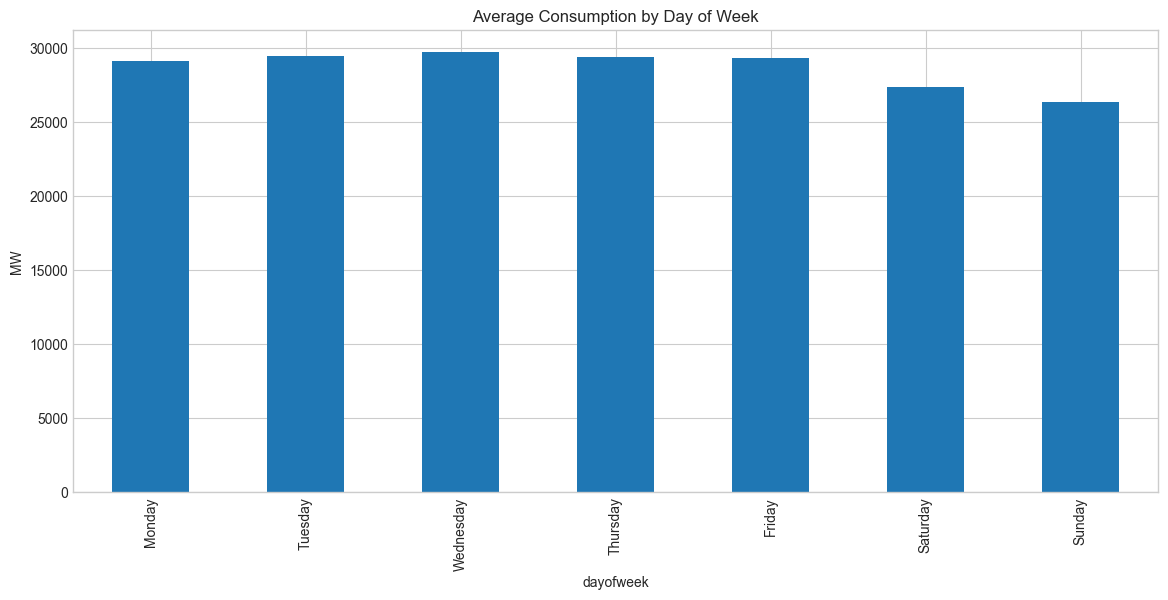

In [99]:
energy['dayofweek'] = energy['time'].dt.day_name()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
energy.groupby('dayofweek')['total load actual'].mean().reindex(order).plot(kind='bar', title='Average Consumption by Day of Week')
plt.ylabel('MW')
plt.show()

There's some dip in consumption over the weekend.

## 3. Distribution - Target Variable

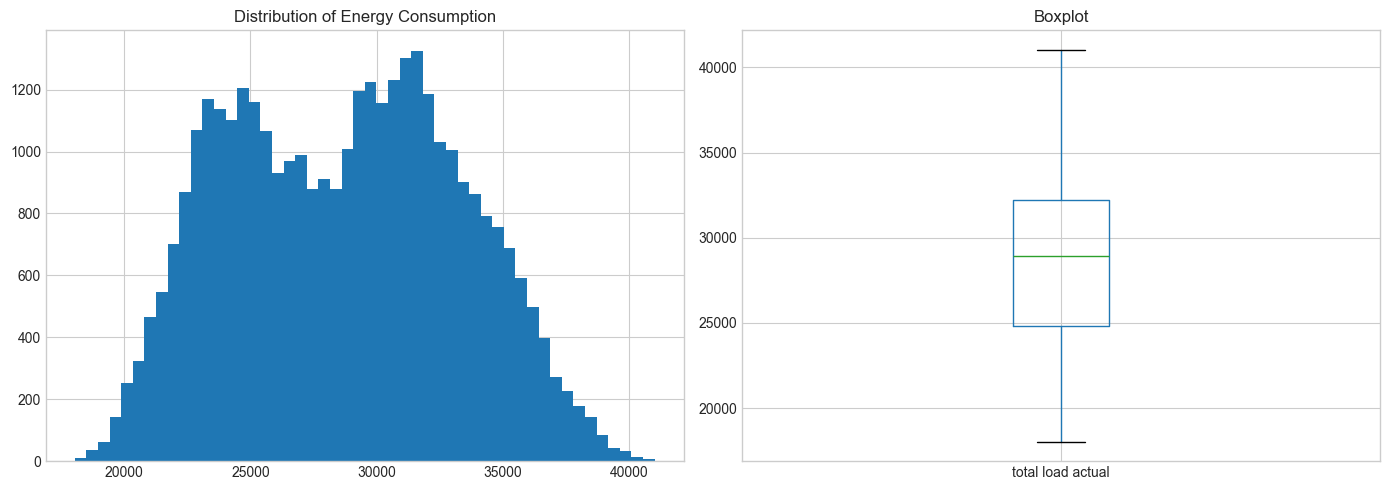

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
energy['total load actual'].hist(bins=50, ax=axes[0])
axes[0].set_title('Distribution of Energy Consumption')
energy.boxplot(column='total load actual', ax=axes[1])
axes[1].set_title('Boxplot')
plt.tight_layout()
plt.show()

There are two distinct peaks, one around 23,000-24,000 MW and another around 30,000-31,000 MW showing overall bimodial distribution.  
The lower peak is likely nighttime/weekend hours, the higher peak is weekday daytime.  
No extreme outliers, the boxplot looks clean.  
Slight right skew, the tail extends further on the high end (up to ~42,000) than the low end.

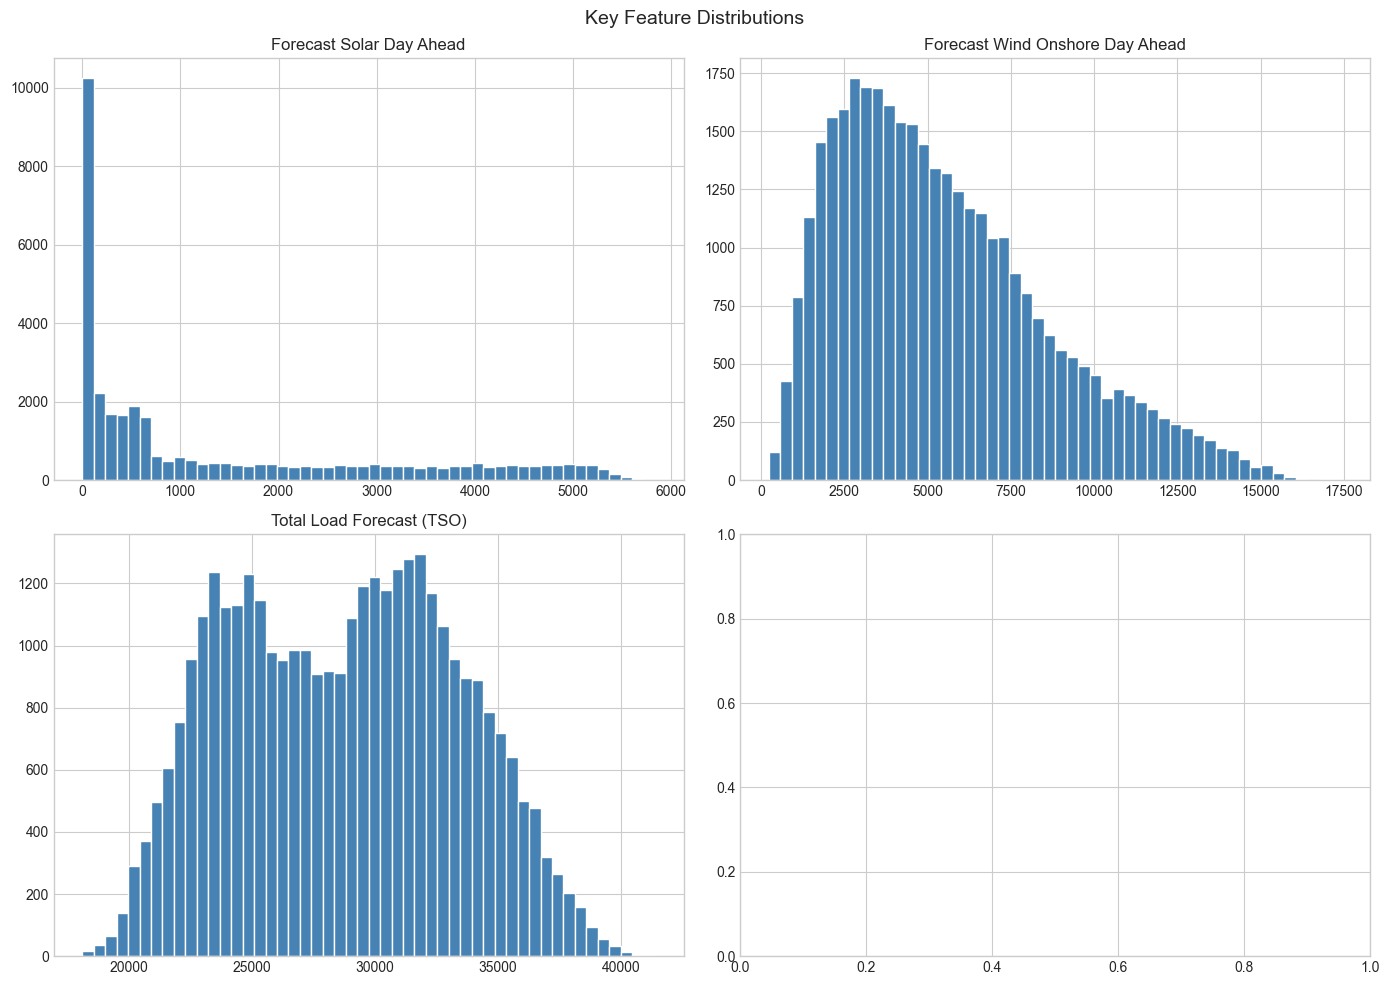

In [107]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

energy['forecast solar day ahead'].hist(bins=50, ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Forecast Solar Day Ahead')

energy['forecast wind onshore day ahead'].hist(bins=50, ax=axes[0,1], color='steelblue', edgecolor='white')
axes[0,1].set_title('Forecast Wind Onshore Day Ahead')

energy['total load forecast'].hist(bins=50, ax=axes[1,0], color='steelblue', edgecolor='white')
axes[1,0].set_title('Total Load Forecast (TSO)')

plt.suptitle('Key Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

The solar forecast includes many zeros, likely for nighttime hours, meaning that this forecast can be only informative for daytime. Wind forecast is right-skewed but continuous, providing signal at all hours. The TSO load forecast mirrors the target distribution closly.

## 4. Weather Data

In [108]:
weather.head()

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2014-12-31 23:00:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 00:00:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 01:00:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 02:00:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 03:00:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


In [109]:
print('Cities:', weather['city_name'].unique())
weather.info()

Cities: ['Valencia' 'Madrid' 'Bilbao' ' Barcelona' 'Seville']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178396 entries, 0 to 178395
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   dt_iso               178396 non-null  datetime64[ns]
 1   city_name            178396 non-null  object        
 2   temp                 178396 non-null  float64       
 3   temp_min             178396 non-null  float64       
 4   temp_max             178396 non-null  float64       
 5   pressure             178396 non-null  int64         
 6   humidity             178396 non-null  int64         
 7   wind_speed           178396 non-null  int64         
 8   wind_deg             178396 non-null  int64         
 9   rain_1h              178396 non-null  float64       
 10  rain_3h              178396 non-null  float64       
 11  snow_3h              178396 non-null  float64       
 12  clouds_all

No missing values. ' Barcelona' has a leading space. Temperature is in Kelvin. Categorical weather columns (weather_main etc) are excluded from modelling.